In [5]:
# Polynomial Regression on cleaned_property_data
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt    
import seaborn as sb   

# Load the cleaned dataset (update the path if needed)
df = pd.read_csv('cleaned_property_data.csv')

# Use all features except the target
target_col = 'Super Buildup Rate (per sq.ft.)'
X = df.drop(columns=[target_col])
y = df[target_col]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create polynomial features (degree=2 as example)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Fit the model
model = LinearRegression()
model.fit(X_train_poly, y_train)

# Predict
y_pred = model.predict(X_test_poly)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('Mean Squared Error:', mse)
print('R2 Score:', r2)


Mean Squared Error: 0.0019662251719909656
R2 Score: 0.9978502942957195


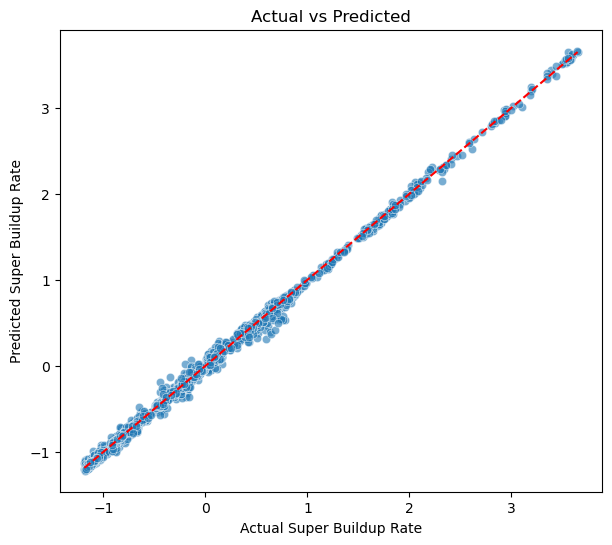

In [6]:
plt.figure(figsize=(7,6))
sb.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # 45° line
plt.xlabel("Actual Super Buildup Rate")
plt.ylabel("Predicted Super Buildup Rate")
plt.title("Actual vs Predicted")
plt.show()